In [51]:
# patent_choropleth_static.py
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import numpy as np
from shapely.geometry import Point

# Settings
CSV_PATH = "data.csv"
SHAPEFILE_PATH = "cb_2015_us_cbsa_500k.shp"
YEAR = "2015"
ID_COL_CSV = "ID Code"
AREA_NAME_COL = "Mj Area Name"
OUTPUT_PNG = "patent_choropleth_static.png"
TOP_N = 5
FIGSIZE = (14, 9)

# 1) Load
df = pd.read_csv(CSV_PATH, encoding="latin-1")
gdf = gpd.read_file(SHAPEFILE_PATH)

# 2) prepare columns
df = df[[ID_COL_CSV, AREA_NAME_COL, YEAR]].copy()
df.columns = ["GEOID", "NAME", "Patent_Count"]
df["GEOID"] = df["GEOID"].astype(str).str.strip()
df["Patent_Count"] = pd.to_numeric(df["Patent_Count"], errors="coerce").fillna(0).astype(int)

gdf["GEOID"] = gdf["GEOID"].astype(str).str.strip()

# 3) Merge
merged = gdf.merge(df[[ "Patent_Count", "NAME"]], on="NAME", how="left")
merged["Patent_Count"] = merged["Patent_Count"].fillna(0).astype(int)


/var/folders/gr/0mtj9_rn5pj2n_fft10k5zs40000gn/T/ipykernel_75687/1133647052.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("OrRd")  # try "OrRd" for warm contrast; swap to "plasma" if you prefer


Saved static map to patent_choropleth_static.png


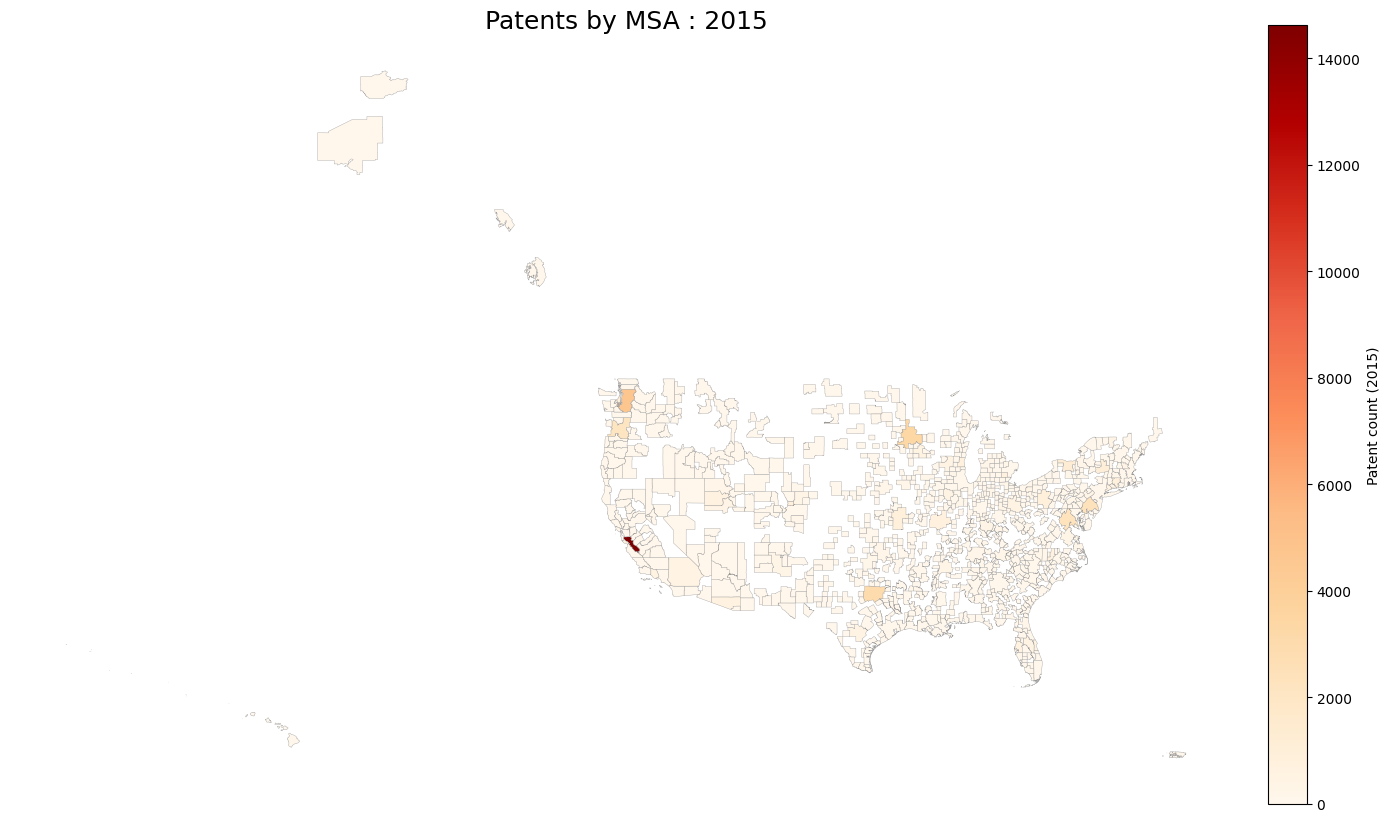

In [54]:
# 4) CRS & centroids
if merged.crs is None:
    merged = merged.set_crs(epsg=4326)

# project for centroid calc and plotting in meters (EPSG:3857)
merged_proj = merged.to_crs(epsg=3857)
centroids_proj = merged_proj.geometry.centroid
centroids_wgs = gpd.GeoSeries(centroids_proj, crs=merged_proj.crs).to_crs(epsg=4326)
merged["centroid_lon"] = centroids_wgs.x
merged["centroid_lat"] = centroids_wgs.y

# 5) Decide normalization: use LogNorm if data skewed
pat_min = merged["Patent_Count"].min()
pat_max = merged["Patent_Count"].max()
# avoid LogNorm if min <= 0 or max/min < 100 (not very skewed)
use_log = (pat_min > 0) and (pat_max / max(pat_min, 1) > 100)

if use_log:
    norm = LogNorm(vmin=max(pat_min, 1e-3), vmax=pat_max)
else:
    norm = Normalize(vmin=pat_min, vmax=pat_max)

# 6) Plot
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)

# pick a more contrasting colormap: 'OrRd' or 'plasma' are good choices
cmap = cm.get_cmap("OrRd")  # try "OrRd" for warm contrast; swap to "plasma" if you prefer

# Plot (in projected CRS)
merged_proj.plot(
    column="Patent_Count",
    cmap=cmap,
    linewidth=0.25,
    edgecolor="0.6",
    ax=ax,
    norm=norm,
)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label(f"Patent count ({YEAR})")

# Title & aesthetics
ax.set_title(f"Patents by MSA : {YEAR}", fontsize=18)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=300)
print(f"Saved static map to {OUTPUT_PNG}")
plt.show()

/var/folders/gr/0mtj9_rn5pj2n_fft10k5zs40000gn/T/ipykernel_75687/178726698.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("OrRd")


Saved static map to patent_choropleth_static.png


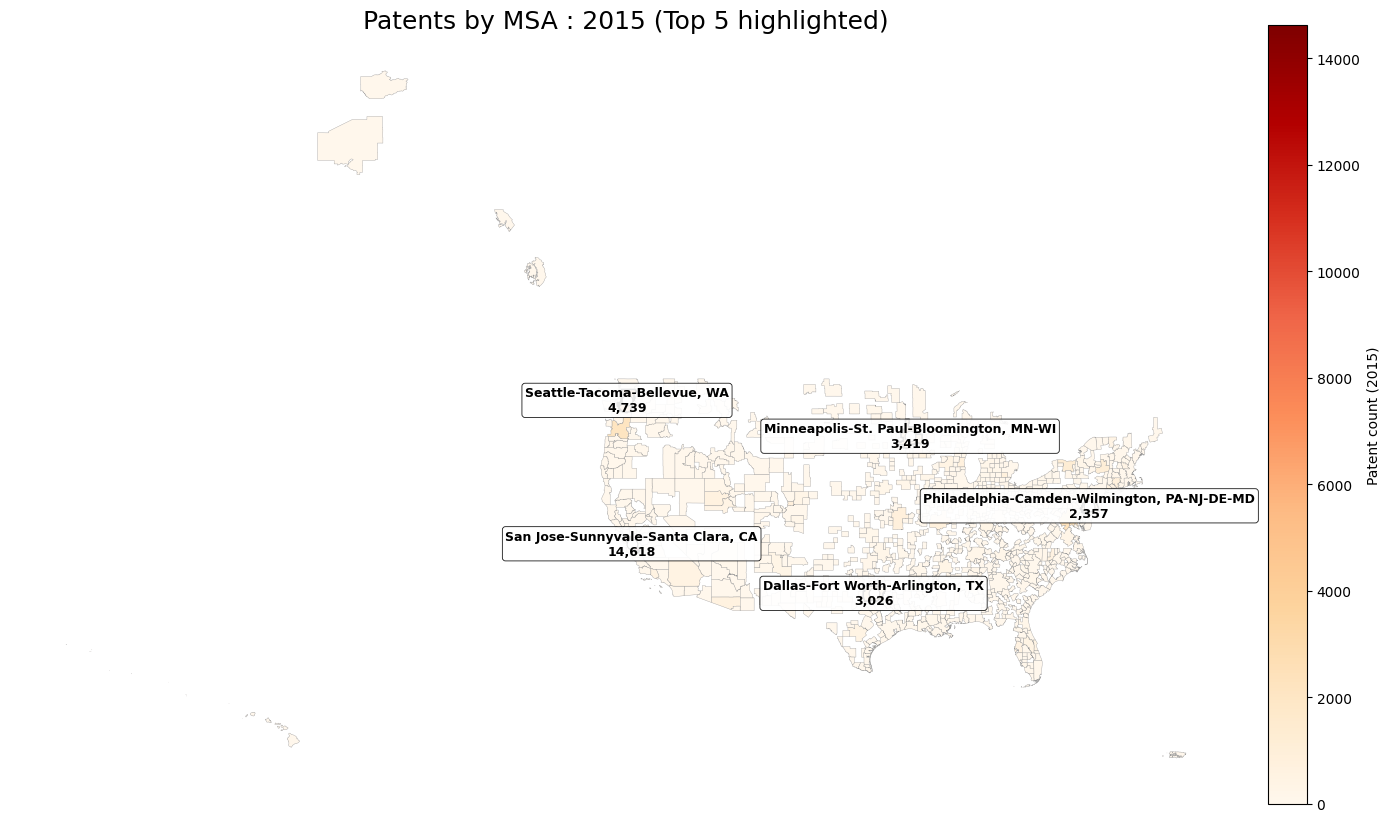

In [55]:
if merged.crs is None:
    merged = merged.set_crs(epsg=4326)

merged_proj = merged.to_crs(epsg=3857)
centroids_proj = merged_proj.geometry.centroid
centroids_wgs = gpd.GeoSeries(centroids_proj, crs=merged_proj.crs).to_crs(epsg=4326)
merged["centroid_lon"] = centroids_wgs.x
merged["centroid_lat"] = centroids_wgs.y

# 5) Top-N
top = merged.nlargest(TOP_N, "Patent_Count").copy()
# If Area_Name missing in shapefile, fallback to CSV name:
top["label_name"] = top["NAME"].fillna(top.get("NAME", top["GEOID"]))

# 6) Norm & cmap
pat_min = merged["Patent_Count"].min()
pat_max = merged["Patent_Count"].max()
use_log = (pat_min > 0) and (pat_max / max(pat_min, 1) > 100)
if use_log:
    norm = LogNorm(vmin=max(pat_min, 1e-3), vmax=pat_max)
else:
    norm = Normalize(vmin=pat_min, vmax=pat_max)

cmap = cm.get_cmap("OrRd")

# 7) Plot base map
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
merged_proj.plot(
    column="Patent_Count",
    cmap=cmap,
    linewidth=0.25,
    edgecolor="0.6",
    ax=ax,
    norm=norm,
)

# 8) Highlight top-N: thicker black outline + small circle marker + label
# project the top geometries to plotting CRS
top_proj = top.to_crs(epsg=3857)
# draw thicker outlines for top N
top_proj.boundary.plot(ax=ax, linewidth=1.2, edgecolor="black", zorder=6)

# add markers and labels for top N
for idx, row in top.iterrows():
    lon = row["centroid_lon"]
    lat = row["centroid_lat"]
    name = row.get("Area_Name", row.get("NAME", row["GEOID"]))
    count = int(row["Patent_Count"])

    # convert lon/lat to plot coords (EPSG:3857)
    pt_proj = gpd.GeoSeries([Point(lon, lat)], crs="EPSG:4326").to_crs(epsg=3857)
    px, py = pt_proj.geometry.x.iloc[0], pt_proj.geometry.y.iloc[0]

    # marker
    ax.scatter(px, py, s=60, marker='o', facecolor='white', edgecolor='black', linewidth=0.8, zorder=7)

    # label box
    label = f"{name}\n{count:,}"
    ax.text(px, py, label,
            fontsize=9, fontweight="bold", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.9, lw=0.6),
            zorder=8)

# 9) Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label(f"Patent count ({YEAR})")

# Title & aesthetics
ax.set_title(f"Patents by MSA : {YEAR} (Top {TOP_N} highlighted)", fontsize=18)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=300)
print(f"Saved static map to {OUTPUT_PNG}")
plt.show()
